## Fraud detection using credit cards transaction dataset
The Institute of International Finance and Deloitte LLP highlights that: There is growing consensus that the current global framework for fighting financial crime is not as effective as it could be and that more needs to be done at the international, regional and national levels to help identify and stem the flow of illicit finance – an activity which supports some of the worst problems confronting society today, including terrorism, sexual exploitation, modern slavery, wildlife poaching and drug smuggling.

Whilst these problems in themselves are pressing and need a multifacted approach for resolution, financial institutions are facing even greater pressure to modernize and make more robust their AML functions for various risk management objectives.

ML has transformed the KYC processess and transaction monitoring functions. To further improve the customer onboarding there is need to contsantly improve the customer due dilligence processs (CDD) through recalllibration of these models and effective model governance.

In this project you will use dataset found in Kaggle containing transcation made in Sept 2013 by European card holders which occured in the course of 2 days. This dataset presents transactions that occurred in two days, where we have 492 frauds out of 284,807 transactions. The dataset is highly unbalanced, the positive class (frauds) account for 0.172% of all transactions. It contains only numerical input variables which are the result of a PCA transformation. Unfortunately, due to confidentiality issues more background cannot be provided about the features.

Features V1, V2, … V28 are the principal components obtained with PCA, the only features which have not been transformed with PCA are 'Time' and 'Amount'. Feature 'Time' contains the seconds elapsed between each transaction and the first transaction in the dataset. The feature 'Amount' is the transaction Amount, this feature can be used for example-dependant cost-sensitive learning. Feature 'Class' is the response variable and it takes value 1 in case of fraud and 0 otherwise.

Given the class imbalance ratio, we recommend measuring the accuracy using the Area Under the Precision-Recall Curve (AUPRC). Confusion matrix accuracy is not meaningful for unbalanced classification.

In this project you will use and learn about the various oversampling and undersampling techniques are why these are useful in varous classfication problems.

You will also get to lean why different classification metrics are used in the case of unbalanced data.

You will find the following information useful in understanding the nature of the presented features.

Every customer has a unique profile. That is their geoographical location, spending frequency and amounts.
The transactions happen in different terminals, merchants, or ATMs which are based in certain geographical locations.
There is an association of customers to terminals in the sense that customers are likely to make transactions in terminals geographically close to their locations.

## Import libraries and uploading data

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings
import itertools
import random

from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler,RobustScaler, StandardScaler, PolynomialFeatures
from imblearn.over_sampling import SMOTE
from sklearn.svm import LinearSVC, SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report, precision_score, recall_score
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
data = pd.read_csv(r'C:\Users\USER\OneDrive\Desktop\machine_learning\Week4\creditcard.csv')
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## EDA & Data cleaning

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
data.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [5]:
data.duplicated().sum()

np.int64(1081)

In [6]:
data = data.drop_duplicates()

In [7]:
data.shape

(283726, 31)

The dataset was examined for quality issues, and no missing values were found across any of the features. However, 1,081 duplicate records were identified, most of which were legitimate transactions. These duplicates were removed to avoid biasing the model further towards the majority class. After cleaning, the final dataset consisted of 283,726 unique transactions.

# Distribution

Univeriate Analysis

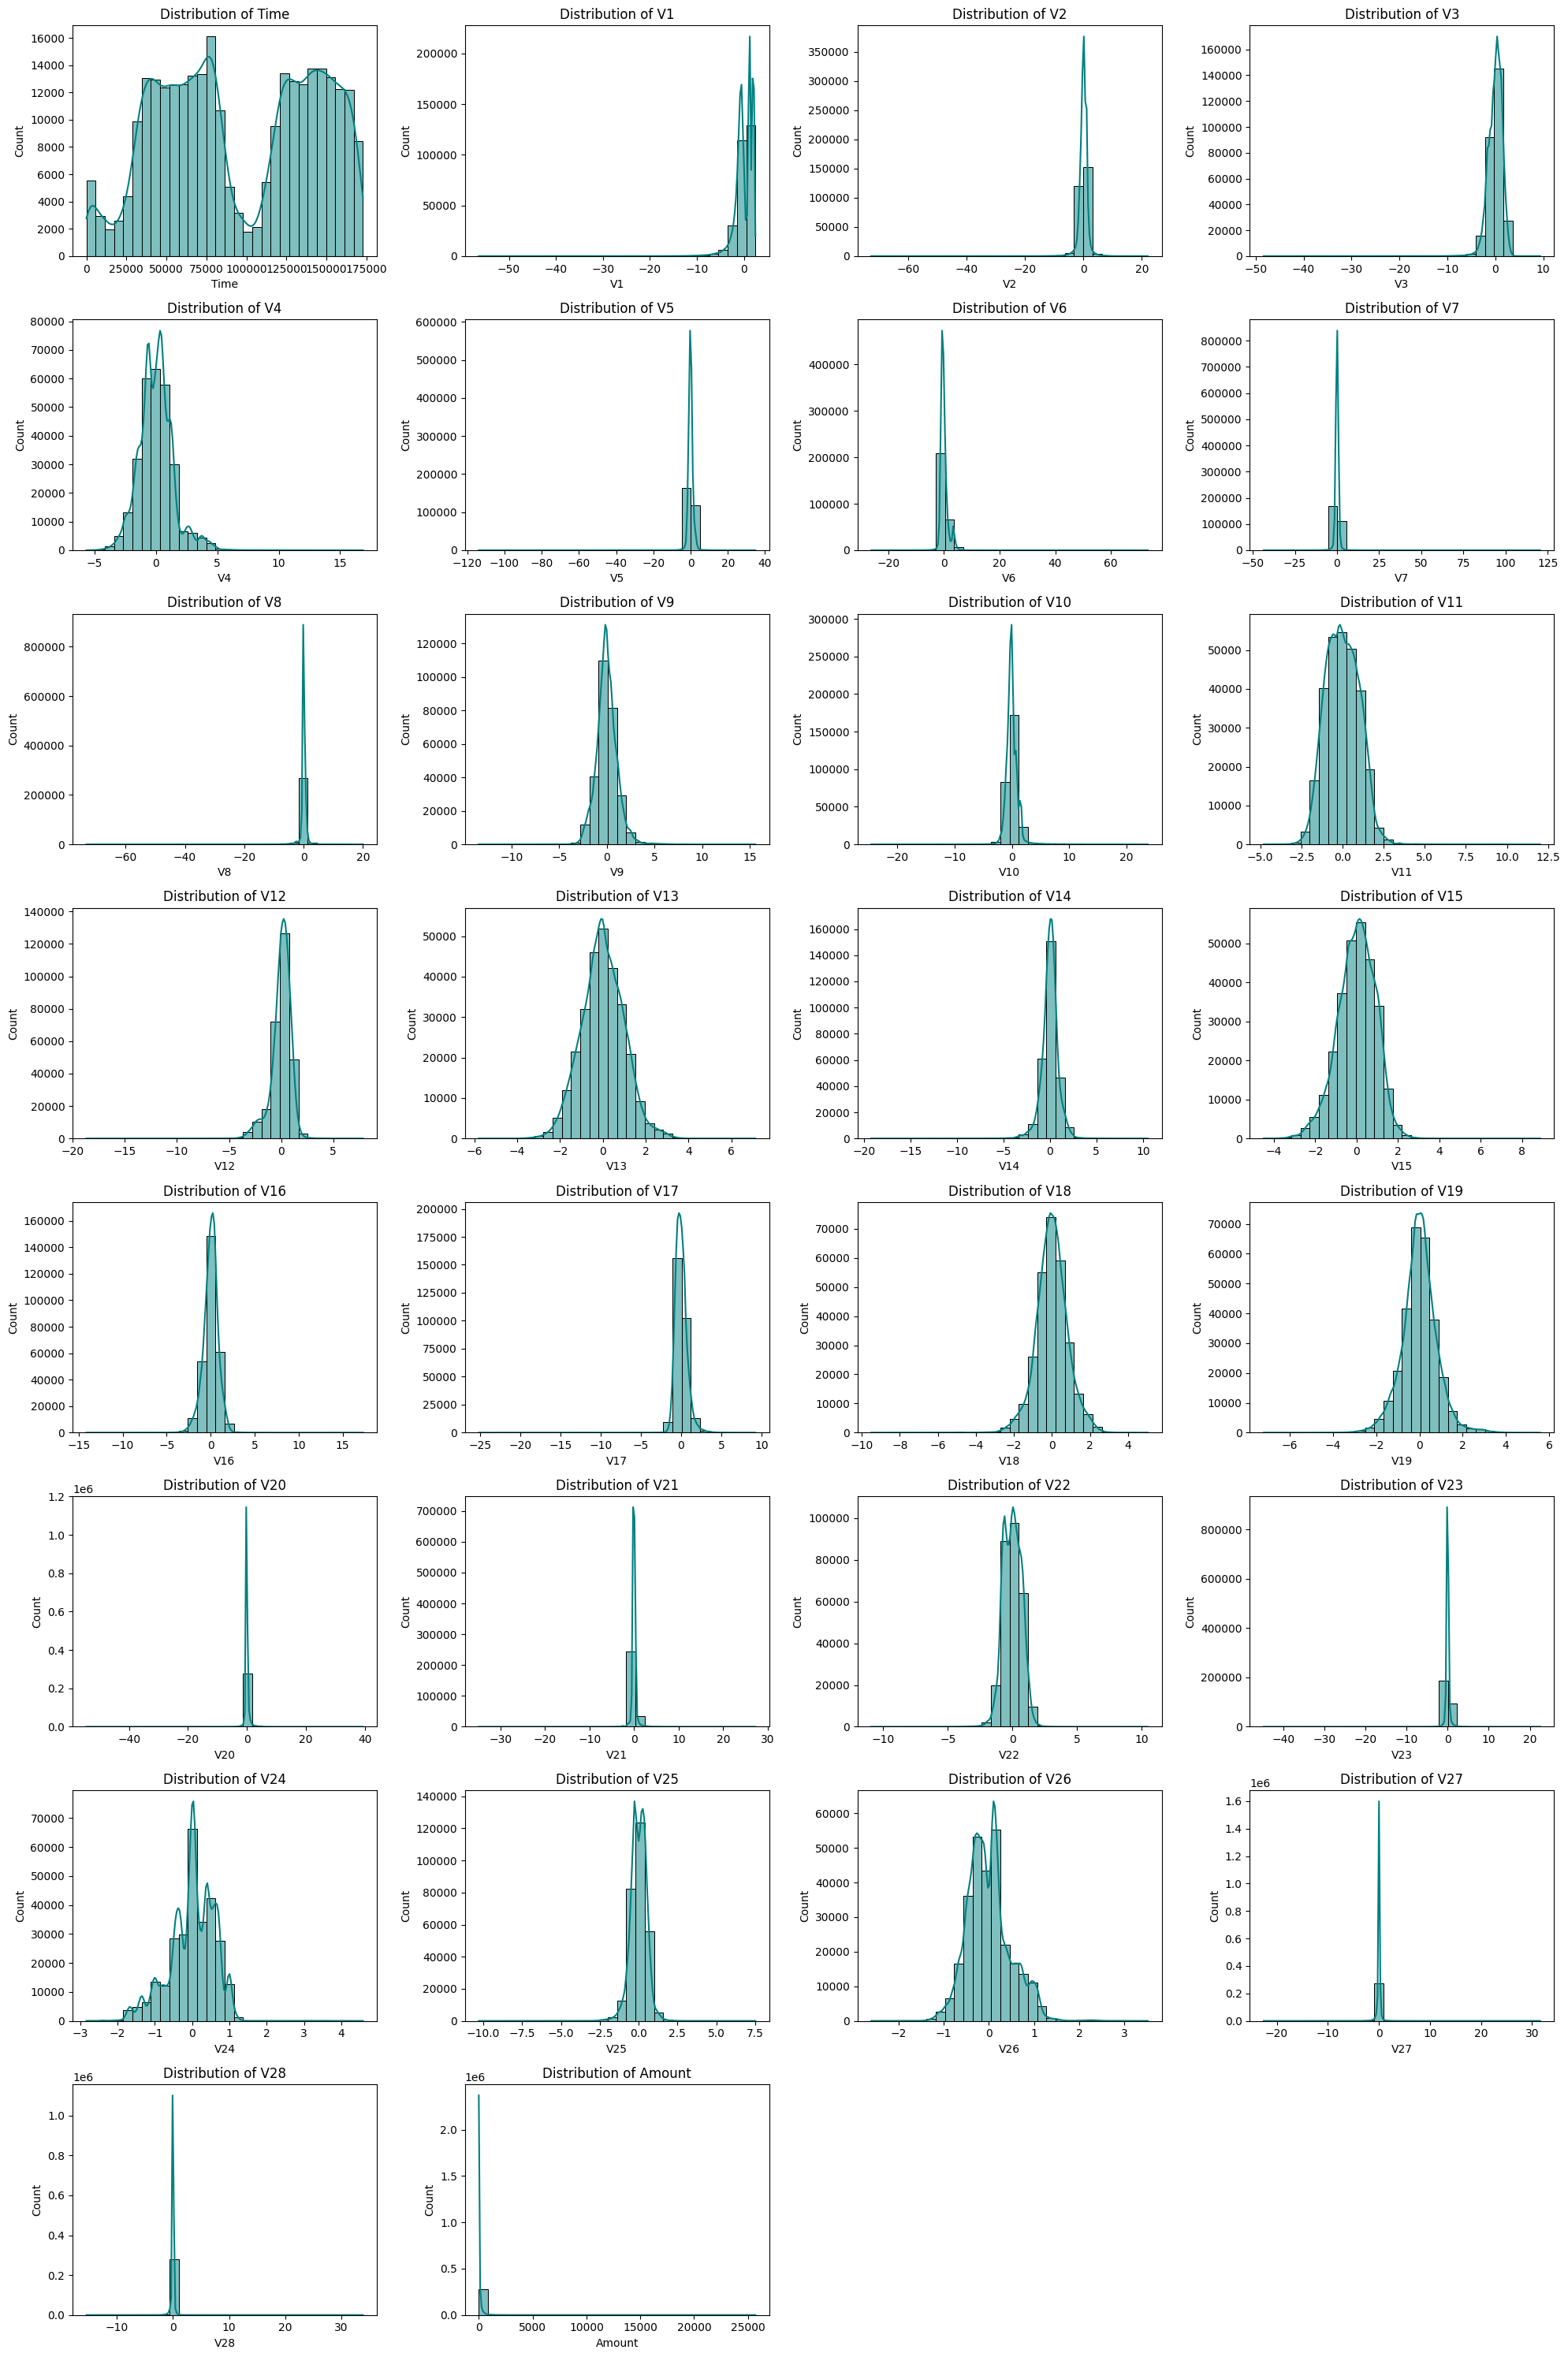

In [8]:
numeric_cols = data.drop("Class", axis=1).columns  

fig, axes = plt.subplots(8, 4, figsize=(20, 30))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(data[col], bins=30, kde=True, ax=axes[i], color="teal")
    axes[i].set_title(f"Distribution of {col}")

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- Time: Fairly uniform distribution
- Amount: Highly right-skewed
- V1, V2, V3, V4, V5, V6, V7, V8, V9: Show skewed distributions with long tails
- V10, V11, V12, V13, V14, V15, V16, V17: Closer to normal distributions, but with varying spread.
- V18, V19, V20, V21, V22, V23, V24: Roughly centered around zero with moderate skewness
- V25, V26, V27, V28: More compact distributions with most values tightly clustered near zero, though occasional outliers exist.
- Class: Extremely imbalanced

Biveriate Analysis

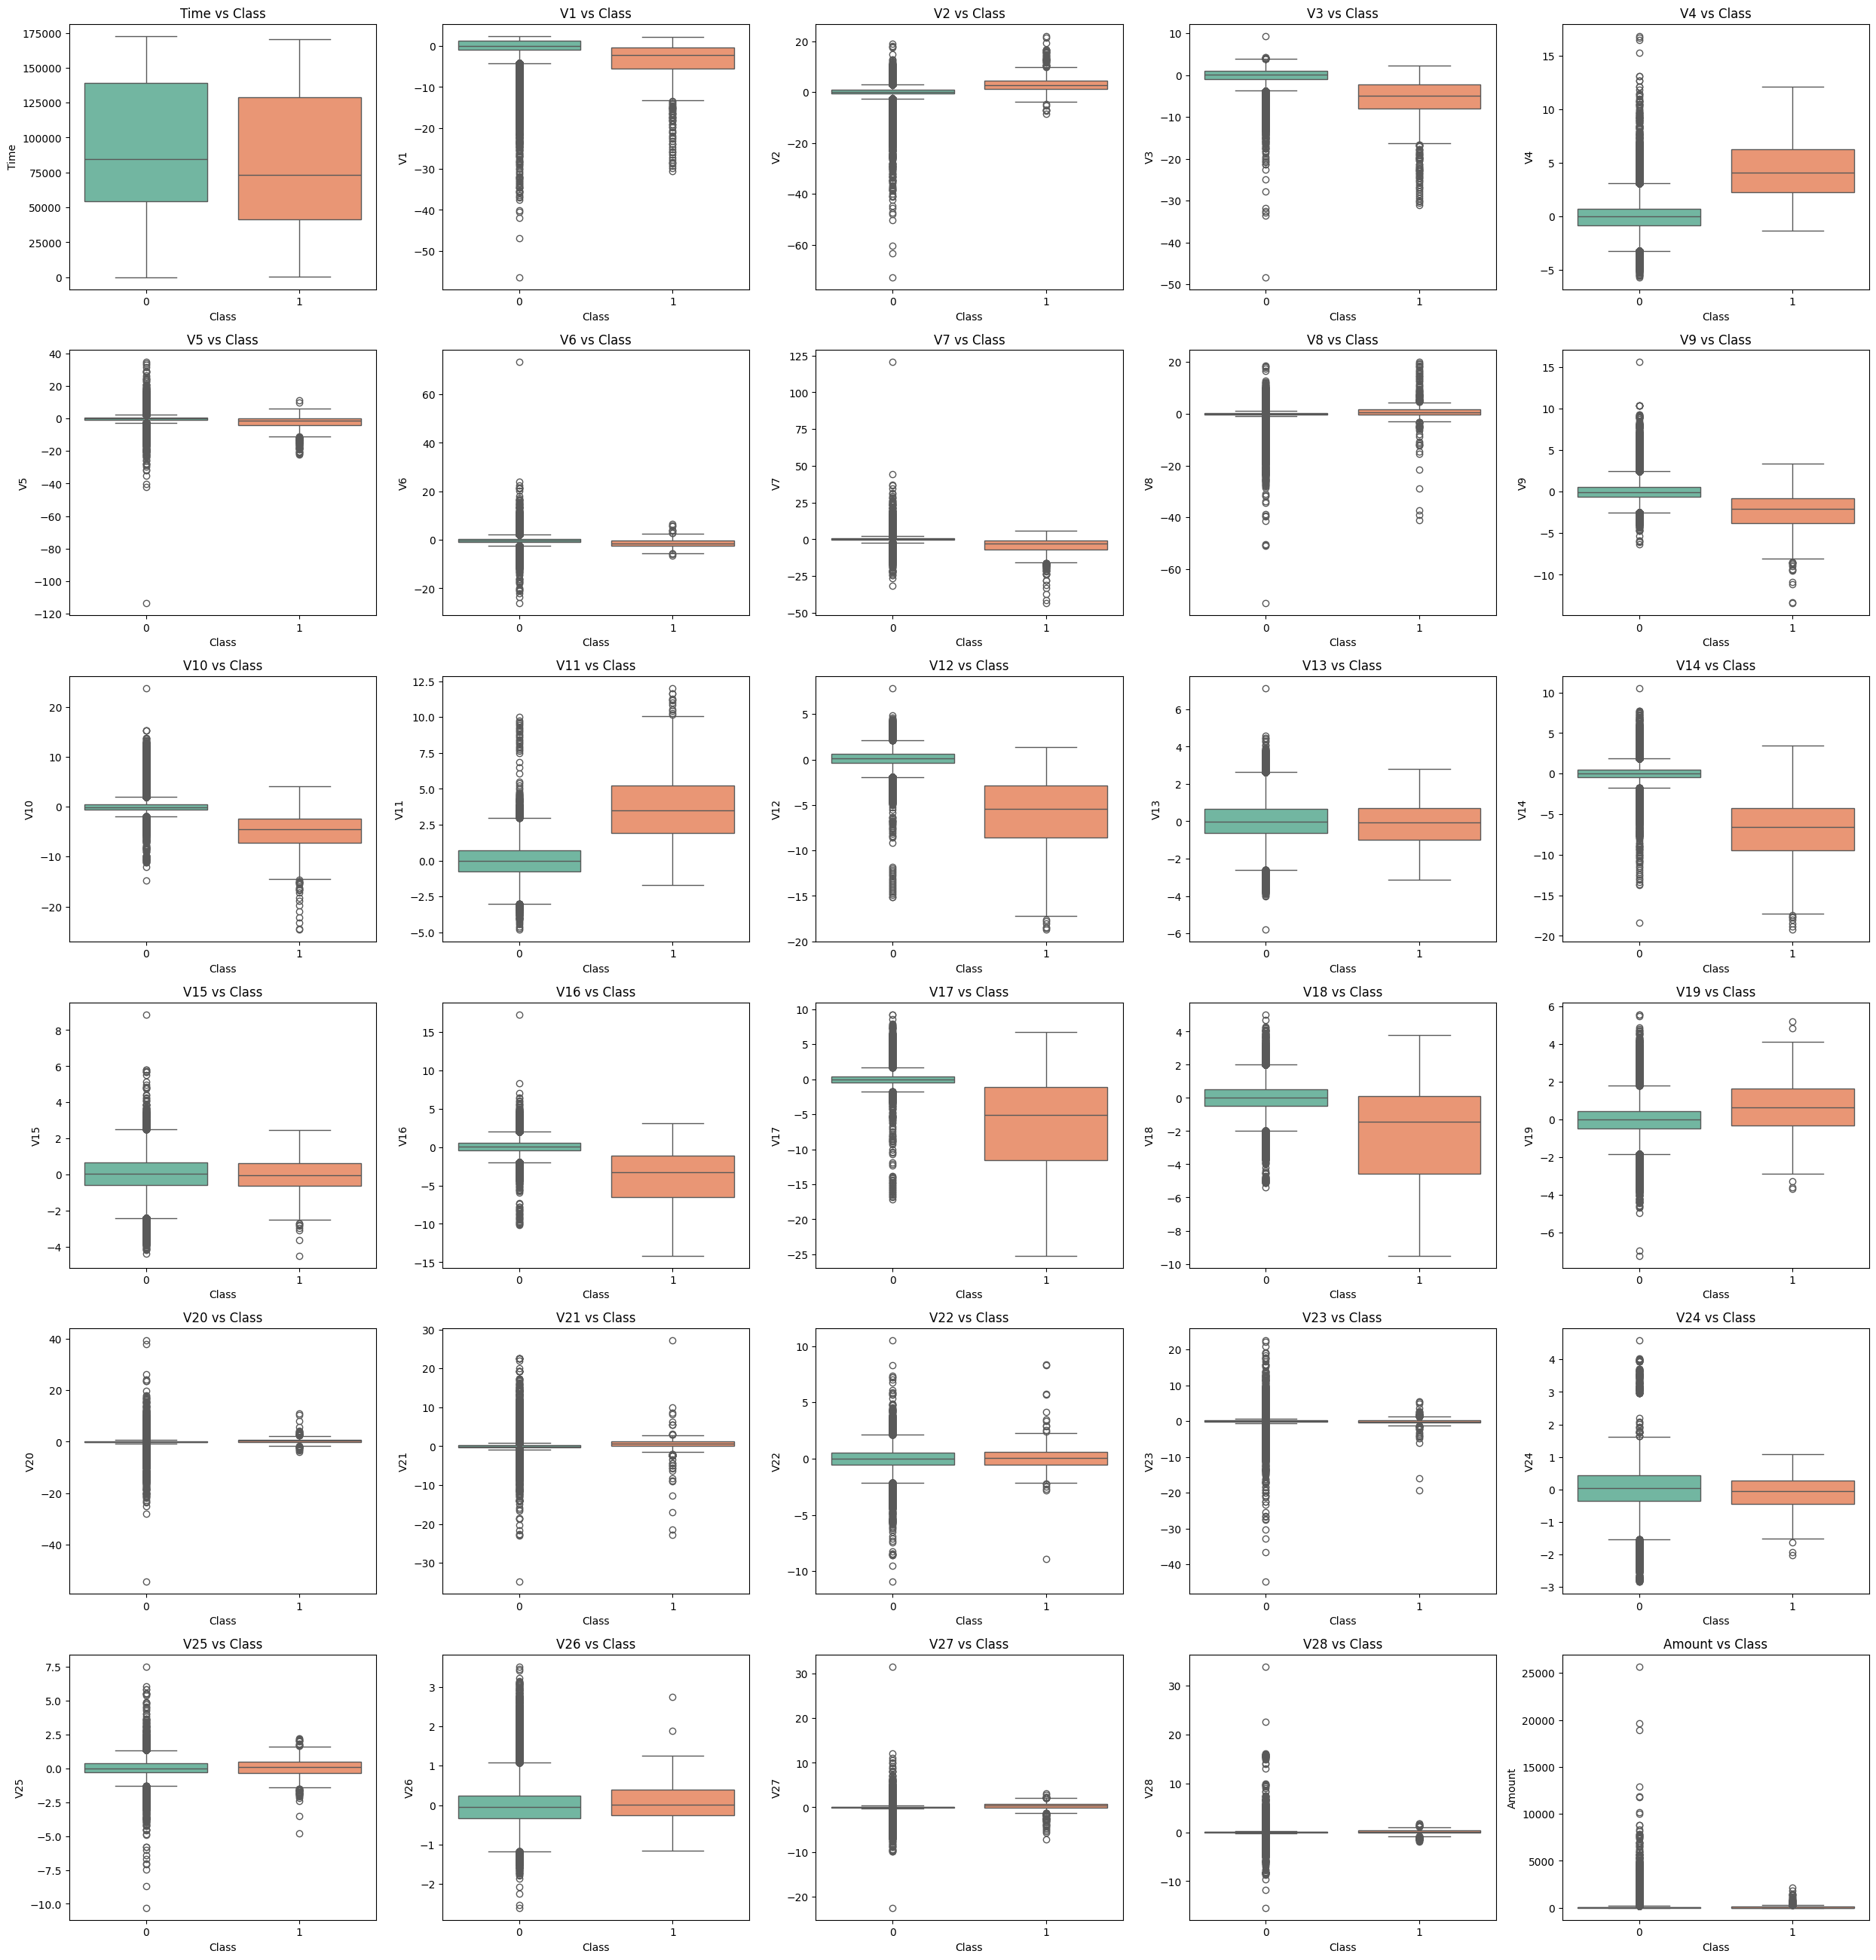

In [9]:
numeric_cols = data.drop("Class", axis=1).columns  

fig, axes = plt.subplots(7, 5, figsize=(25, 30))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(
        x="Class", 
        y=col, 
        data=data,
        hue="Class", 
        dodge=False, 
        legend=False, 
        palette="Set2", 
        ax=axes[i]
    )
    axes[i].set_title(f"{col} vs Class")
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- The bivariate analysis shows that fraudulent transactions are more concentrated in earlier time periods compared to legitimate ones, indicating possible temporal clustering of fraud. In terms of transaction amount, fraud cases tend to involve smaller values on average, although a few high-value frauds are also present. This suggests that both time and amount provide useful signals for distinguishing fraudulent activity from normal transactions.
- Bivariate analysis was not performed on features V1–V28 since they are PCA-transformed components with no direct business interpretation.

Correlation

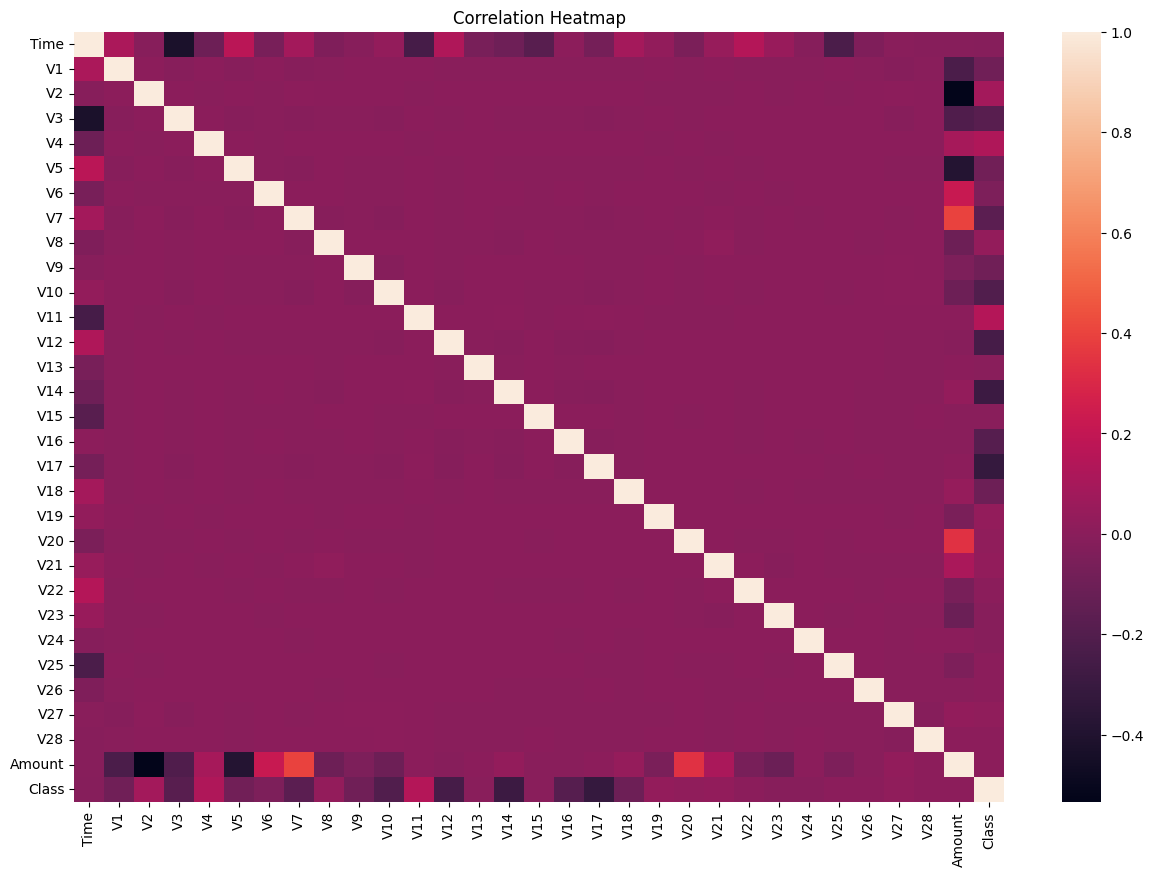

In [10]:
plt.figure(figsize=(15,10))
sns.heatmap(data.corr(), annot=False)
plt.title("Correlation Heatmap")
plt.show()

Linear Seperability

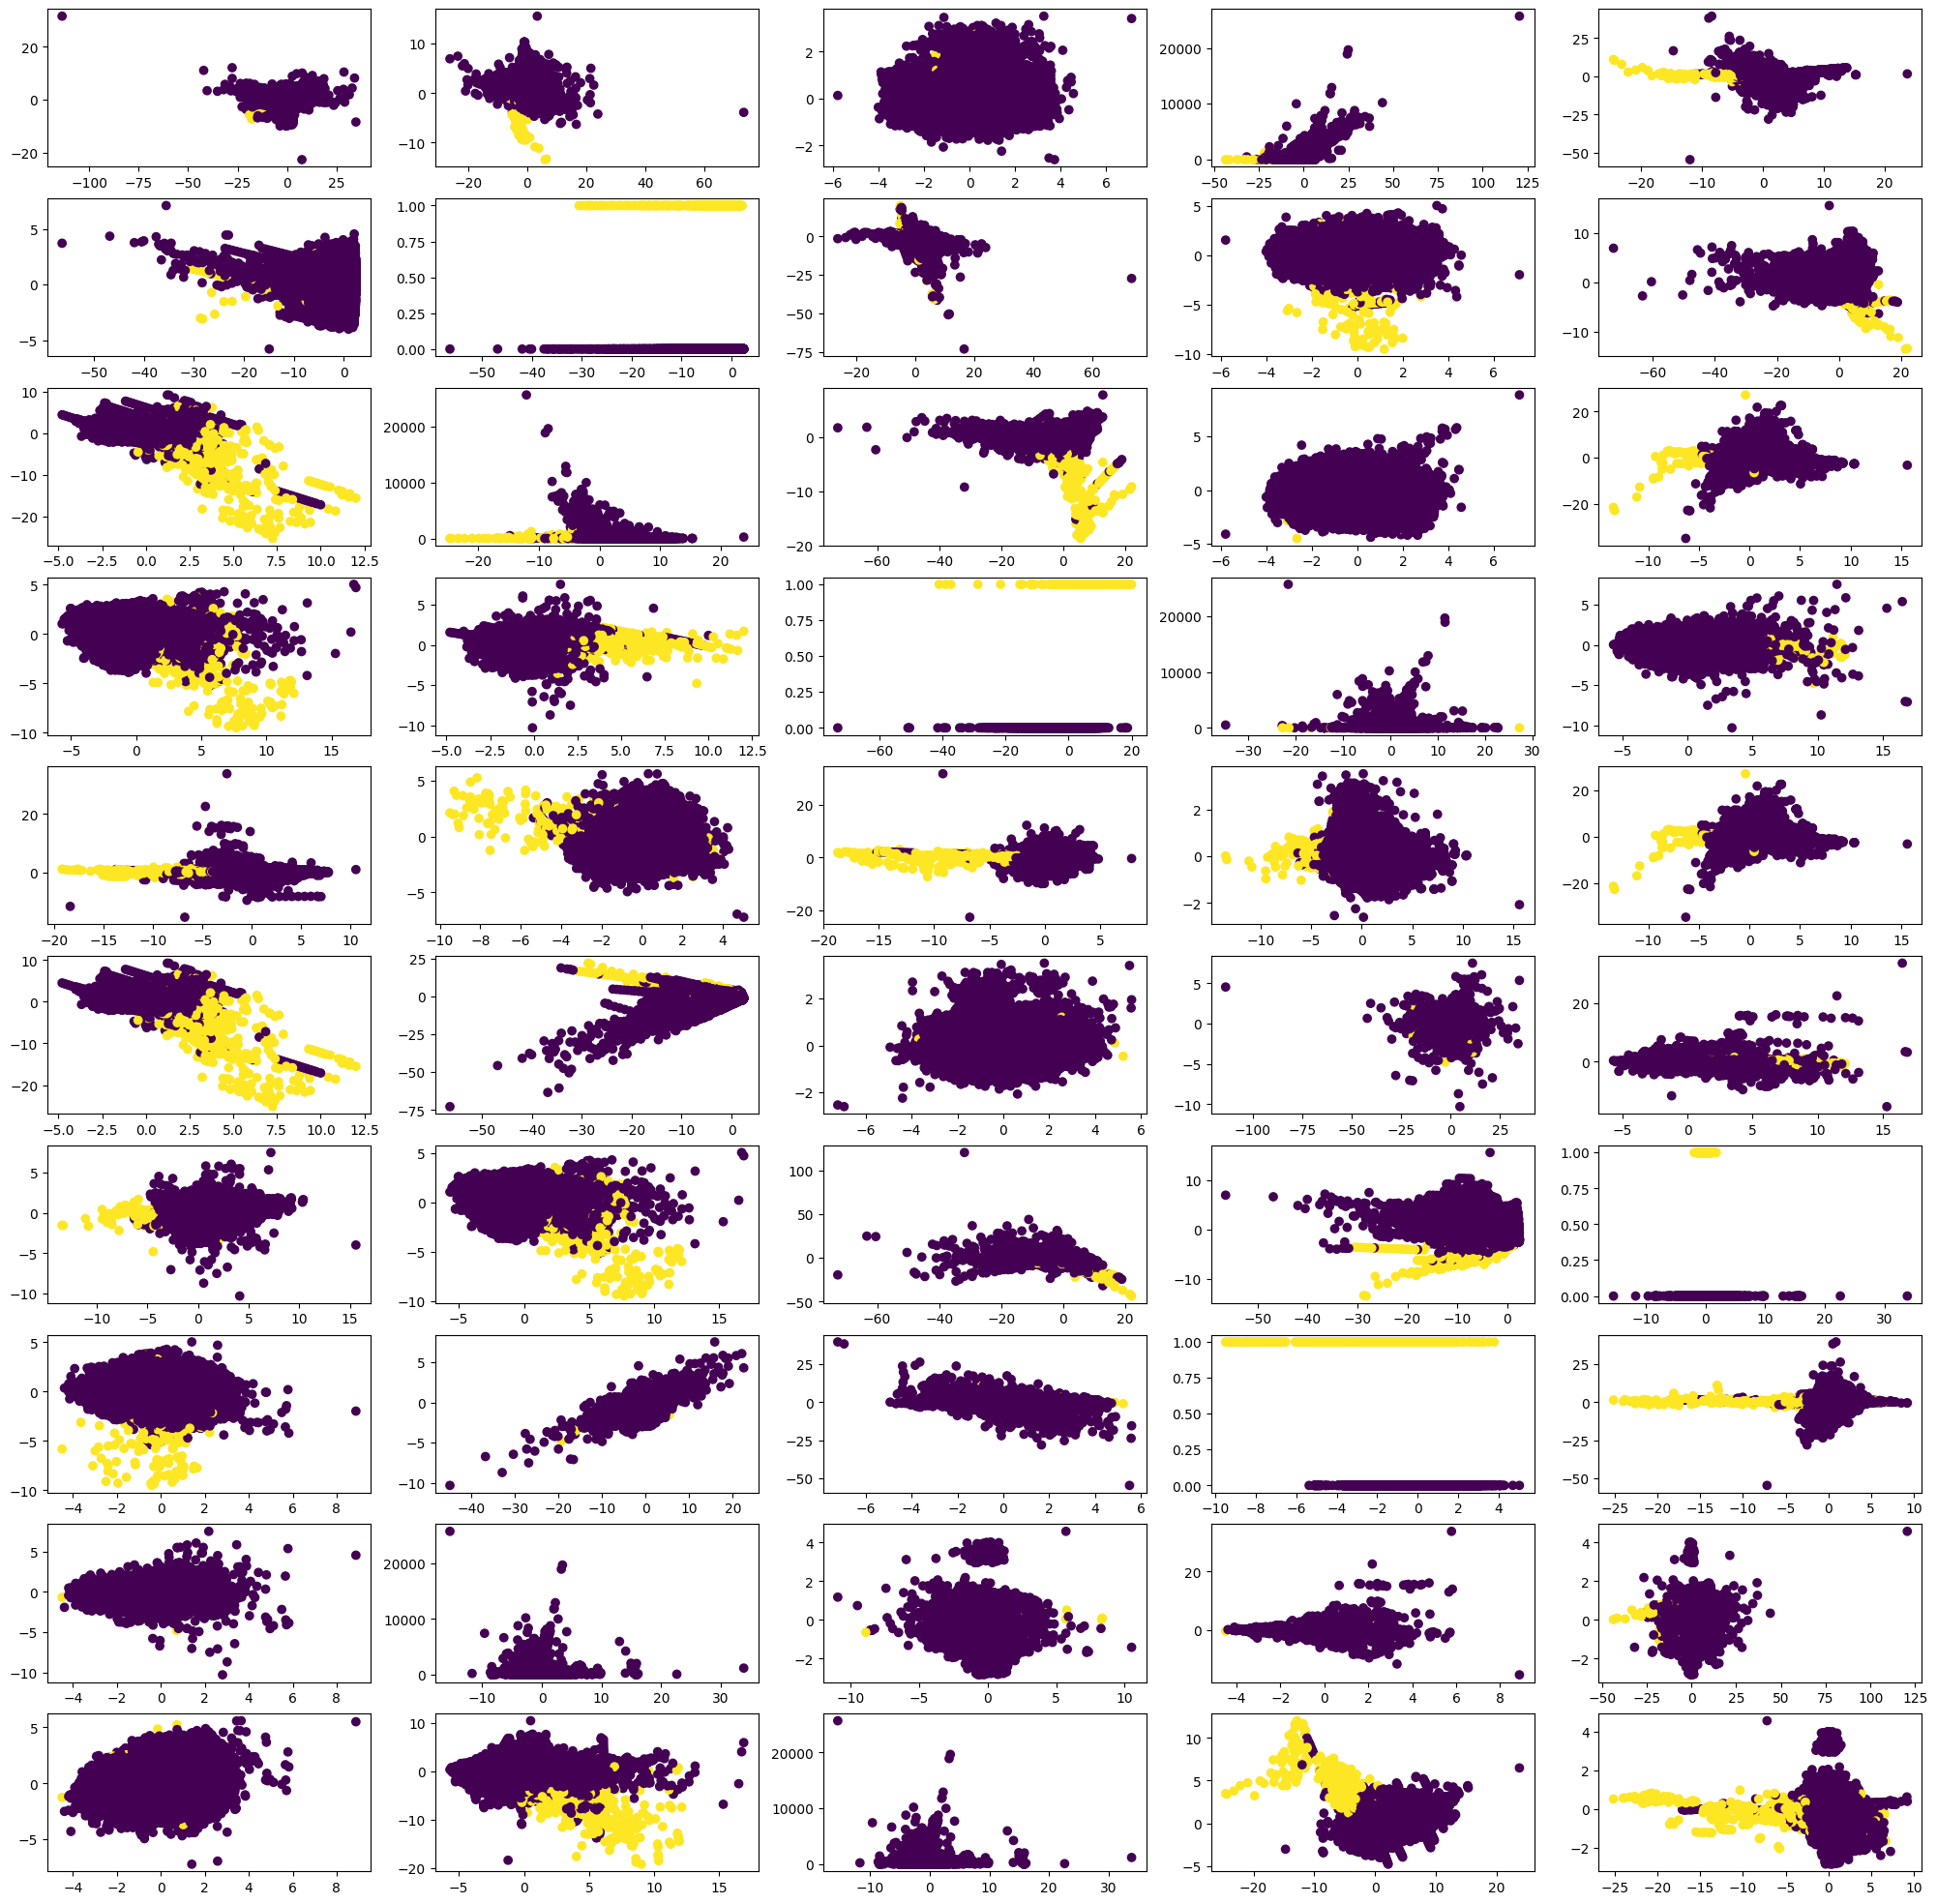

In [12]:
comb = list(itertools.combinations([a for a in range(1, len(data.columns))], 2))
rand = random.choices(comb, k=50)

fig = plt.figure(figsize=(25,25))
for i in range(len(rand)):
    ax = fig.add_subplot(10,5, i+1)
    plt.scatter(
        data[data.columns[rand[i][0]]],
        data[data.columns[rand[i][1]]],
        c=data["Class"]
    )

Class Imbalance Handling

In [11]:
from sklearn.utils import resample
X = data.drop("Class", axis=1)
y = data["Class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_majority = X_train[y_train == 0]
y_majority = y_train[y_train == 0]

X_minority = X_train[y_train == 1]
y_minority = y_train[y_train == 1]

X_minority_upsampled, y_minority_upsampled = resample(
    X_minority,
    y_minority,
    replace=True,
    n_samples=int(0.3 * len(y_majority)),
    random_state=42
)

X_train_res = pd.concat([X_majority, X_minority_upsampled])
y_train_res = pd.concat([y_majority, y_minority_upsampled])

print("After upsampling:")
print(y_train_res.value_counts())

After upsampling:
Class
0    226597
1     67979
Name: count, dtype: int64


The dataset is highly imbalanced, with fraud cases making up only 0.172% of all transactions. To address this, SMOTE oversampling was applied to balance the training data, allowing models to better detect fraud.

## Model selection

In [12]:
# Scaling
scaler = StandardScaler()
X_train_res_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

In [16]:
#Logistic Regression (No Regularisation)
pipe = make_pipeline(PolynomialFeatures(degree=1),LogisticRegression(C=1e10, solver='lbfgs', max_iter=10000, random_state=42))
scores = cross_val_score(pipe, X_train_res_scaled, y_train_res, cv=5, scoring="accuracy")
print(scores, scores.mean())

[0.97082287 0.97100908 0.96944751 0.97187473 0.97099211] 0.9708292597034152


In [17]:
# KNN
pipe = make_pipeline(StandardScaler(),PolynomialFeatures(degree=2, include_bias=False),KNeighborsClassifier(n_neighbors=5))
scores = cross_val_score(pipe, X_train_res_scaled, y_train_res, cv=5, scoring="accuracy")
print(scores, scores.mean())

[0.99940593 0.99960961 0.9994229  0.99969448 0.99927013] 0.9994806096717852


In [18]:
# Support vector classification - RBF Kernel
pipe = make_pipeline(PolynomialFeatures(degree=2), SVC(kernel='rbf',C=25))
scores = cross_val_score(pipe, X_train_res_scaled, y_train_res, cv=5, scoring="accuracy")
print(scores, scores.mean())

[0.9921753  0.99249767 0.99095307 0.9924128  0.9923449 ] 0.9920767472619861


In [ ]:
# Support vector classification - Linear Kernel
pipe = make_pipeline(PolynomialFeatures(degree=2), LinearSVC(C=50))
scores = cross_val_score(pipe, X_train_res_scaled, y_train_res, cv=5, scoring="accuracy")
print(scores, scores.mean())

[0.99784122 0.99773108 0.99777513 0.99900872 0.99845801] 0.998162833729844


In [ ]:
# Decision tree
pipe = make_pipeline(StandardScaler(),PolynomialFeatures(degree=2, include_bias=False),DecisionTreeClassifier(random_state=42, max_depth=10))
scores = cross_val_score(pipe, X_train_res_scaled, y_train_res, cv=5, scoring="accuracy")
print(scores, scores.mean())

[0.99942726 0.99922901 0.99949335 0.99933915 0.99933915] 0.9993655828707375


In [14]:
# Random Forest - Entropy
pipe = make_pipeline(PolynomialFeatures(degree=1),RandomForestClassifier(criterion='entropy', random_state=42))
scores = cross_val_score(pipe, X_train_res_scaled, y_train_res, cv=5, scoring="accuracy")
print(scores, scores.mean())

[0.99993211 1.         0.99991513 0.99994908 0.99991513] 0.9999422899699338


In [ ]:
# Random Forest - Gini
pipe = make_pipeline(PolynomialFeatures(degree=1),RandomForestClassifier(n_estimators=300,max_depth=10,criterion='gini'))
scores = cross_val_score(pipe, X_train_res_scaled, y_train_res, cv=3, scoring="accuracy")
print(scores, scores.mean())

[0.99952419 0.99957706 0.99951097] 0.9995374041765794


Among all the models tested, Random Forest achieved the best overall performance, handling the complex feature interactions and class imbalance more effectively than Logistic Regression, KNN, or SVM.

# Metrics measurement

In [16]:
pipe = make_pipeline(
    PolynomialFeatures(degree=1),
    RandomForestClassifier(criterion="entropy", random_state=42)
)

scores = cross_val_score(pipe, X_train_res_scaled, y_train_res, cv=5, scoring="f1")
print("Cross-validated F1:", scores.mean())

pipe.fit(X_train_res_scaled, y_train_res)

y_pred = pipe.predict(X_test_scaled)
y_pred_proba = pipe.predict_proba(X_test_scaled)[:,1]

# Test metrics
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_pred_proba))

Cross-validated F1: 0.9998749835076719
Accuracy : 0.9995241955380115
Precision: 0.9565217391304348
Recall   : 0.7333333333333333
F1 Score : 0.8301886792452831
ROC-AUC  : 0.9310281935423139


## Error analysis

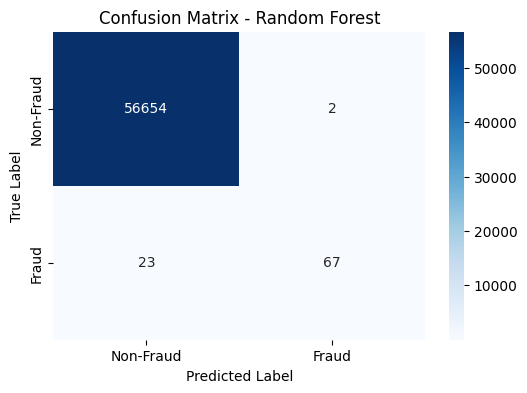

Classification Report:

              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     56656
       Fraud       0.97      0.74      0.84        90

    accuracy                           1.00     56746
   macro avg       0.99      0.87      0.92     56746
weighted avg       1.00      1.00      1.00     56746

False Positives: 2 (Non-Fraud predicted as Fraud)
False Negatives: 23 (Fraud missed as Non-Fraud)


In [21]:
rf_final = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42)
rf_final.fit(X_train_res_scaled, y_train_res)

# Predictions
y_pred = rf_final.predict(X_test_scaled)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Fraud","Fraud"], yticklabels=["Non-Fraud","Fraud"])
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.title("Confusion Matrix - Random Forest")
plt.show()

# Classification Report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Non-Fraud","Fraud"]))

# Error Analysis
false_positives = X_test[(y_test == 0) & (y_pred == 1)]
false_negatives = X_test[(y_test == 1) & (y_pred == 0)]

print(f"False Positives: {len(false_positives)} (Non-Fraud predicted as Fraud)")
print(f"False Negatives: {len(false_negatives)} (Fraud missed as Non-Fraud)")

The Random Forest model performs well overall, achieving nearly perfect accuracy and a weighted F1 score of 1.00 due to the dominance of the Non-Fraud class. For Fraud detection, the model achieves 97% precision (few false alarms) but only 74% recall, meaning it misses some actual fraud cases. Specifically, there were 2 false positives (normal transactions flagged as fraud) and 23 false negatives (fraudulent transactions missed).

## Learning and validation curve

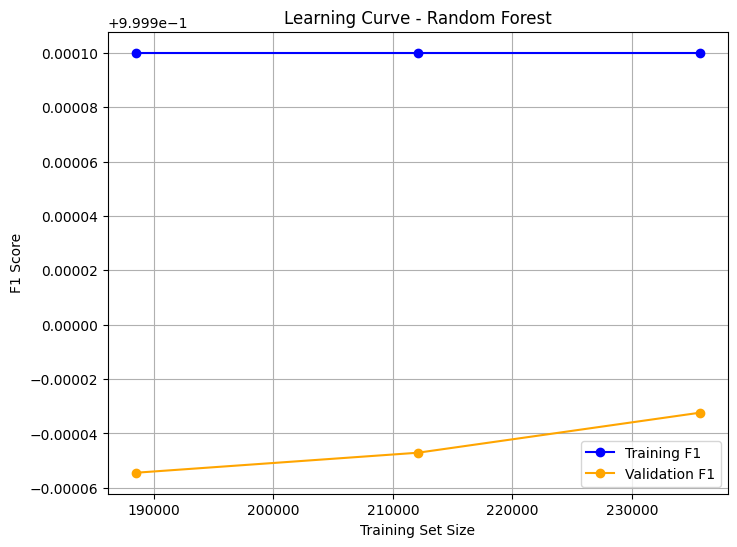

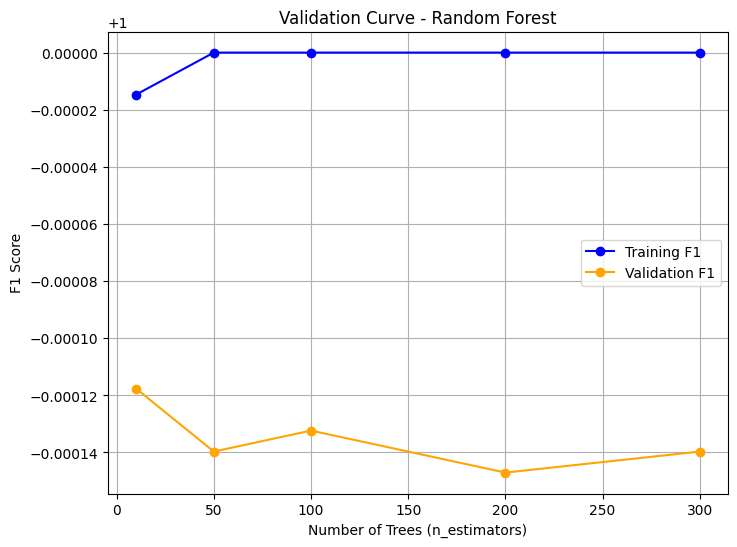

In [17]:
# Learning Curve
train_sizes, train_scores, val_scores = learning_curve(
    RandomForestClassifier(random_state=42),
    X_train_res_scaled, y_train_res,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, 'o-', label="Training F1", color="blue")
plt.plot(train_sizes, val_mean, 'o-', label="Validation F1", color="orange")
plt.xlabel("Training Set Size")
plt.ylabel("F1 Score")
plt.title("Learning Curve - Random Forest")
plt.legend()
plt.grid()
plt.show()

# Validation Curve
param_range = [10, 50, 100, 200, 300]
train_scores, val_scores = validation_curve(
    RandomForestClassifier(random_state=42),
    X_train_res_scaled, y_train_res,
    param_name="n_estimators",
    param_range=param_range,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(8,6))
plt.plot(param_range, train_mean, 'o-', label="Training F1", color="blue")
plt.plot(param_range, val_mean, 'o-', label="Validation F1", color="orange")
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("F1 Score")
plt.title("Validation Curve - Random Forest")
plt.legend()
plt.grid()
plt.show()

The validation curve shows that increasing the number of trees beyond 50 does not significantly improve F1 scores for either training or validation. Training F1 remains almost perfect, while validation F1 stays consistently low, suggesting the model may be overfitting and not generalizing well.

The learning curve indicates that the training F1 score is near-perfect across all training set sizes, while the validation F1 remains much lower. The small upward trend in validation F1 as training size increases suggests that more data might help, but the persistent gap confirms overfitting and limited generalization power.